# Section 1: Intro - Deep Learning Pipeline

This notebook provides a baseline implementation using a Convolutional Neural Network (CNN) for handwritten digit classification on the MNIST dataset. It presents a complete PyTorch-based training pipeline, covering all stages from data preprocessing to model inference.

1. Data Preprocessing
2. Model
3. Training Loop
4. Monitoring
5. Validation
6. Inference

By the end of this module you should:

- Understand the full deep learning training pipeline.
- Run training on GPU.
- Analyze convergence behavior.
- Refactor notebook code into modular structure.
- Prepare for controlled engineering experiments.

### Quick CNN Refresher

**Key concepts:**

1. **Convolution layer**
   - Applies a set of **filters/kernels** to the input
   - Detects local patterns (edges, textures)
2. **Stride & Padding**
   - **Stride** controls how the filter moves
   - **Padding** adds zeros around input to control output size
3. **Output size**
   - For a 2D convolution:

$$
O = \frac{I - K + 2P}{S} + 1
$$

   where:
   - \(I\) = input size
   - \(K\) = kernel size
   - \(P\) = padding
   - \(S\) = stride
   - Often, we want **input and output sizes to match** → use `padding=(kernel_size-1)//2`
4. **Activation (ReLU)**
   - Adds non-linearity
5. **Pooling (optional)**
   - Reduces spatial size (downsampling)


## Section 2 - Environment and Device


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
# Additional info if CUDA
if torch.cuda.is_available():
    print(f"Number of GPUs available: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory Allocated: {torch.cuda.memory_allocated(i)/1024**2:.2f} MB")
        print(f"  Memory Cached   : {torch.cuda.memory_reserved(i)/1024**2:.2f} MB")
        print(f"Peak: {torch.cuda.max_memory_allocated()/1024**2:.2f} MB")
else:
    import platform
    print(f"CPU Info: {platform.processor()}")
    
# Python and CUDA version
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version  : {torch.version.cuda}")

Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 3050 Ti Laptop GPU
  Memory Allocated: 0.00 MB
  Memory Cached   : 0.00 MB
Peak: 0.00 MB
PyTorch version: 2.11.0+cu130
CUDA version  : 13.0


## Section 3 - Data Preprocessing

MNIST = Modified National Institute of Standards and Technology

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_subset = Subset(train_dataset, range(100))
test_subset = Subset(test_dataset, range(30))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

In [8]:
data_iter = iter(test_loader)
images, labels = next(data_iter)


In [9]:
img_tensor, label = train_dataset[0]

print("Tensor shape:", img_tensor.shape)
print("Tensor dtype:", img_tensor.dtype)
print("Tensor min:", img_tensor.min().item())
print("Tensor max:", img_tensor.max().item())

Tensor shape: torch.Size([1, 28, 28])
Tensor dtype: torch.float32
Tensor min: -1.0
Tensor max: 1.0


In [10]:
print("Dataset size:", len(train_dataset))
print("Subset size:", len(train_subset))

print("Batch size:", train_loader.batch_size)

print("Number of batches per epoch:", len(train_loader))

Dataset size: 60000
Subset size: 100
Batch size: 64
Number of batches per epoch: 2


Dataset size: 60000
Example label: 5
Raw image type: <class 'torch.Tensor'>
Label: 5


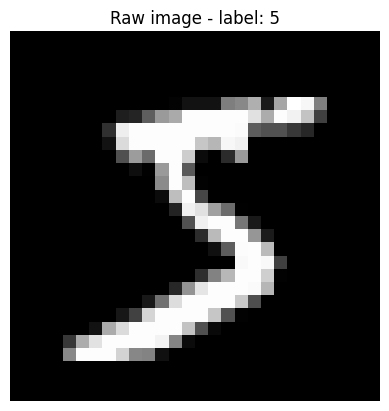

In [11]:
import matplotlib.pyplot as plt

print("Dataset size:", len(train_dataset))
print("Example label:", train_dataset[0][1])

img_raw, label = train_dataset[0]

print("Raw image type:", type(img_raw))
print("Label:", label)

plt.imshow(img_raw.squeeze(), cmap="gray")
plt.title(f"Raw image - label: {label}")
plt.axis("off")
plt.show()

## Section 4 - Model

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1) # (in_channels, out_channels, kernel_size, stride)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128) # (input_features, output_features)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)


## Section 5 - Training Loop with Basic Monitoring using TensorBoard

In PyTorch, the training process is usually written explicitly, meaning we manually specify each step of the optimization procedure. This gives flexibility but also means we need to handle the training workflow ourselves.

In [13]:
from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

# Create a TensorBoard writer
writer = SummaryWriter(log_dir="runs/baseline_experiment")  #tb

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    running_loss = 0.0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad() # PyTorch accumulates gradients by default, so we need to clear them before computing new ones
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    writer.add_scalar("Loss/train", epoch_loss, epoch) #tb

    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader):.4f}")
    


# Example: log images (first batch of training data)
data_iter = iter(train_loader)
images, labels = next(data_iter)
img_grid = vutils.make_grid(images[:8])
writer.add_image("Sample Inputs", img_grid, 0) #tb

# Example: log weight histograms
for name, param in model.named_parameters(): #tb
    writer.add_histogram(f"Weights/{name}", param, epoch) #tb
    
    
# log hyperparameters
hparams = {
    "learning_rate": optimizer.param_groups[0]["lr"],  #tb
    "batch_size": train_loader.batch_size,
    "optimizer": "Adam",
    "epochs": 10
}

metrics = {    #tb
    "hparam/train_loss": epoch_loss 
}

writer.add_hparams(hparams, metrics)  #tb
    
# Run `tensorboard --logdir=runs` to visualize (in terminal)

Epoch 1, Loss: 2.3661
Epoch 2, Loss: 2.0440
Epoch 3, Loss: 1.7292
Epoch 4, Loss: 1.3219
Epoch 5, Loss: 1.0027
Epoch 6, Loss: 0.6171
Epoch 7, Loss: 0.4268
Epoch 8, Loss: 0.2256
Epoch 9, Loss: 0.1733
Epoch 10, Loss: 0.0894


## Section 6 - Validation

In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad(): # disables gradient tracking
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 70.00%


## Section 7 - Inference

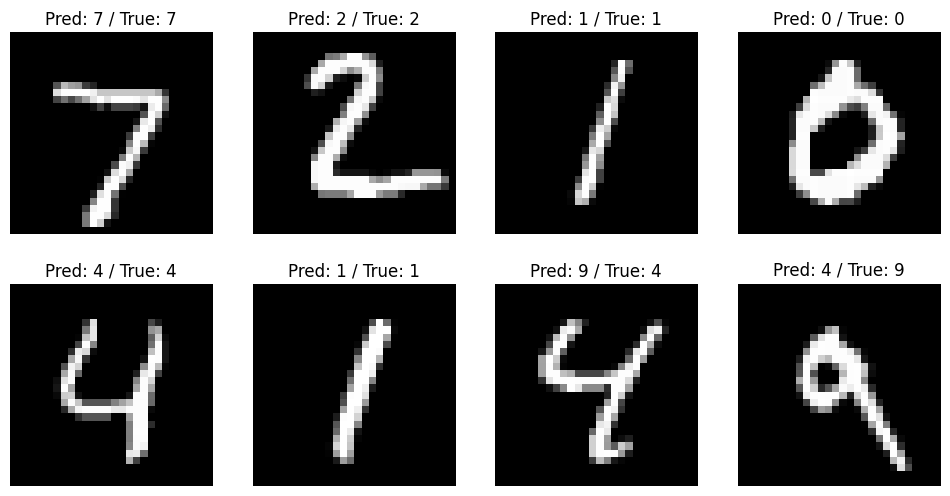

Single image prediction: 7, True label: 7


In [15]:
import matplotlib.pyplot as plt

# Switch model to evaluation mode
model.eval()

# Pick a batch from test set
data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)

# Forward pass
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Display first 8 images with predictions
fig, axes = plt.subplots(2, 4, figsize=(12,6))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu().squeeze()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {preds[i].item()} / True: {labels[i].item()}")
    ax.axis('off')
plt.show()

# Example: Inference on single image
single_img = images[0].unsqueeze(0)  # add batch dimension
output_single = model(single_img)
pred_single = torch.argmax(output_single, dim=1)
print(f"Single image prediction: {pred_single.item()}, True label: {labels[0].item()}")

## Section 8 - Exploration Phase – Your Task

This is your time for exploration. The rules:

1. **Basic Exploration:**  
   - If you explore **at least 3 directions** listed below at least at the **Basic level** you can earn 4.0 (max).
   - Make small experiments, observe results, and take notes.

2. **Deep Exploration:**  
   - Choose **at least one direction** to explore in depth (**Deep level**) (for 5.0).  
   - Conduct a more thorough experiment, log metrics, visualize results, and analyze them.

3. **Be Creative:**  
   - The directions listed are **examples and suggestions**.  
   - If you have your own ideas for exploring this notebook within these directions, feel free to try them.  
   - Innovative approaches are welcome and will be valued.

> Goal: understand all pipeline components, experiment responsibly, and prepare for future extensions and advanced models.


## Section 8 - Directions of Exploration 

### Direction #1 – Engineering Workflow / Modularization

#### Basic:
- Refactor notebook into modular structure:

```
project/
│
├── main.py          # entry point of the training pipeline
├── model.py         # model architecture definition
├── train.py         # training and validation loops
├── preprocessing.py # data loading and preprocessing
├── config.yaml      # experiment configuration (hyperparameters, paths)
└── utils.py         # helper functions (logging, metrics, etc.)
```

- Ensure code runs end-to-end (`python main.py`).

#### Deep:
- Full engineering workflow:
  - CLI arguments
  - Logging
  - Checkpoint saving
  - Config management
- Ensure reproducibility and easy experiment switching.

---

### Direction #2 – Hyperparameter Optimization

Hyperparameters influence how the model learns. In this task you will explore how changing them affects **training dynamics and final performance**.

Use **TensorBoard** to compare experiments.


#### Basic

Change **one hyperparameter** (e.g. learning rate or batch size) and train the model.

Report:
- final **accuracy**
- final **loss**
- brief analysis of **TensorBoard loss curves**


#### Deep

Run **10–20 experiments** tuning combinations of:
- learning rate
- batch size
- optimizer, weight decay

Report:
- table of all trials
- best configuration
- short comparison of **TensorBoard training curves**

Example search strategies:

```python
# Grid search
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64]

for lr in learning_rates:
    for bs in batch_sizes:
        print(lr, bs)
        # train model

# Random search
import random

learning_rates = [0.1, 0.01, 0.001, 0.0001]
batch_sizes = [16, 32, 64, 128]

for trial in range(10):
    lr = random.choice(learning_rates)
    bs = random.choice(batch_sizes)
    print(trial, lr, bs)
    # train model ```

```

> Tip: use different TensorBoard run names (e.g. runs/lr_0.001_bs_64) to compare experiments.

---

### Direction #3 – Architecture Engineering

#### Basic:
- Change **one layer** (add Dropout or BatchNorm) or modify activation.
- Train the model.
- Report:
  - Accuracy
  - Parameter count

####  Deep:
- Compare **different variantions of baseline architecture**:
  - Vary depth (add/remove Conv or Linear layers)
  - Kernel sizes
  - Dropout, BatchNorm
  - different activation functions like: LeakyReLU, ELU, GELU
- Train each model fully.
- Report and analyze:
  - Accuracy
  - Convergence speed
  - Parameter count ``` sum(p.numel() for p in model.parameters()) ```
  - Training time

> Architecture design hints:
- **Typical CNN block**:  
  `Conv → BatchNorm → Activation → (optional Dropout) → Pool`
- **BatchNorm**: after Conv, before Activation  
- **Dropout**: after Linear layers  
- **Extra Conv layers**: before pooling 
- **Extra Linear layers**: before output
- **Activation variants**: try replacing ReLU with LeakyReLU, ELU, or GELU  

---

```python
import torch
import torch.nn as nn
import torch.nn.functional as F

class NewCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv blocks with BatchNorm
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.conv3 = nn.Conv2d(64, 128, 3, 1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Fully connected
        self.fc1 = nn.Linear(128*2*2, 256)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        
    def forward(self, x):
        # Conv Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        
        # Conv Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool2d(x, 2)
        
        x = torch.flatten(x, 1)
        
        # FC Block
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
```
---

### Direction #4 – Training Acceleration & Profiling

#### Basic:

- Measure **training time** and GPU memory usage for current batch size.
- Optionally try:
  - Mixed Precision (AMP)
  - num_workers adjustment in DataLoader

#### Deep:
- Systematic analysis:
  - Compare multiple batch sizes
  - Compare num_workers settings
  - AMP vs FP32 training
  - data loading performance
- Log metrics:
  - Training time
  - GPU memory usage
  - Accuracy


**Useful snippets**:


```python
from torch.cuda.amp import autocast

with autocast():
    output = model(data)
    loss = criterion(output, target)
```

---

### Direction #5 – Reproducibility & Determinism

#### Basic
Investigate **training reproducibility**.

- Train the model **3 times with and out fixing random seeds**.
-  Record:
   - final training loss
   - validation accuracy
  
```python
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
```

#### Deep:
- Run **3+ identical experiments** with different seeds/hardware.
- Explore **sources of non-determinism**.
- Track variability in:
  - Training loss curves
  - Validation accuracy
  - Convergence speed
- Analyze which settings impact reproducibility.
- Document findings in short report.

```python
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
```

---

### Direction #6 – Observability & TensorBoard

#### Basic:
- Log at least:
  - 2 scalars: train_loss, val_loss (or train_acc, val_acc)
  - 1 histogram (e.g., conv1 weights)
  - 1 batch of input images
- Visualize in TensorBoard.

#### Deep:
- Advanced exploration:
  - Multiple scalars (losses, accuracies, learning rate)
  - Histograms: weights, gradients
  - Feature map visualizations (1–3 intermediate layers)
- Compare multiple runs
- Interpret activations, gradients, convergence behavior
- Produce a short analysis report

> Visualizing CNN Feature Maps with PyTorch Hooks and TensorBoard

Convolutional neural networks learn **filters** that detect patterns in images (edges, textures, shapes).  
Each convolutional layer produces **feature maps** — activations that show where a filter detects a pattern in the input.

Normally these internal activations are **hidden inside the model**.  
To inspect them, we can use **PyTorch hooks**.

> What is a Hook?

A **hook** is a function that is automatically executed when a layer performs a **forward pass**.  
It gives us access to:

- the layer input
- the layer output (activations)

Using hooks, we can capture intermediate results **without modifying the model architecture**.

In this example we:

1. Register a **forward hook** on a convolutional layer
2. Save its activations during training
3. Visualize them in **TensorBoard**

To avoid slowing down training, we log feature maps **only for the first batch in each epoch**.

When opening TensorBoard you will be able to:

- observe **how feature maps evolve during training**
- compare early vs later epochs
- explore what the network learns in early convolution layers


> Example Implementation

```python
from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

writer = SummaryWriter("runs/cnn_feature_maps")

# ------------------------------------------------------------
# Storage for activations
# ------------------------------------------------------------
activations = {}

# ------------------------------------------------------------
# Hook definition
# ------------------------------------------------------------
def get_activation(name):
    """
    Returns a hook that stores layer outputs (feature maps).
    """
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook


# ------------------------------------------------------------
# Register hook on a convolutional layer
# ------------------------------------------------------------
# Example: first convolutional layer
model.conv1.register_forward_hook(get_activation("conv1"))


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
global_step = 0

for epoch in range(10):

    model.train()
    running_loss = 0.0

    for batch_idx, (data, target) in enumerate(train_loader):

        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)

        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # optional: log batch-level loss
        writer.add_scalar("Loss/train_batch", loss.item(), global_step)
        global_step += 1

        # ----------------------------------------------------
        # Feature map visualization (first batch of epoch)
        # ----------------------------------------------------
        if batch_idx == 0:

            feature_maps = activations["conv1"]

            # take first image from the batch
            fm = feature_maps[0]

            # limit number of channels for readability
            fm = fm[:16].unsqueeze(1)

            grid = vutils.make_grid(
                fm,
                normalize=True,
                scale_each=True
            )

            writer.add_image(
                "FeatureMaps/conv1",
                grid,
                epoch
            )

    # --------------------------------------------------------
    # Epoch statistics
    # --------------------------------------------------------
    epoch_loss = running_loss / len(train_loader)

    writer.add_scalar(
        "Loss/train_epoch",
        epoch_loss,
        epoch
    )

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")


```

---

### Direction #7 – Data Engineering & Augmentation

#### Basic:
- Apply **one simple transformation** to the dataset:
  - Resize, random crop, flip, rotatio
  - Optionally normalize input data differently
- Train the model with the modified dataset
- Report:
  - Accuracy / loss
  - Observe qualitative changes in sample images

#### Deep:
- Systematic analysis:
  - Analyze trainig data: are classes balanced?
  - Explore different dataset sizes (subsampling or oversampling)
  - Explore class imbalance and its effect on accuracy
  - Apply multiple augmentations and normalizations
- Log results:
  - Training curves for each variant
  - Compare accuracy, convergence, robustness
- Document findings: how dataset size, augmentation, normalization, or imbalance affects model behavior

> Data Augmentation Example

```python

train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor()
])


```

---

### Direction #8 – Extended Inference / Out-of-Distribution (OOD) Testing

#### Basic:
- Pick **1–2 images outside the training/test set** (random images, different style)
- Run inference and record:
  - Predicted class
  - Model confidence (softmax probability) and compare with data from training/validation sets
- Observe and comment on how the model behaves on unfamiliar inputs

#### Deep:
- Systematic OOD study:
  - Prepare a small set of OOD images (different datasets, rotated/corrupted images)
  - Run inference on all OOD inputs
  - Compare predictions, confidence distributions, and errors
- Visualize:
  - Softmax confidence histograms
  - Example misclassifications
- Analyze:
  - Robustness to OOD inputs
  - How model uncertainty reflects unfamiliar data
- Suggest improvements for future experiments (e.g., augmentation, training on more diverse data)


---

### Direction #9: Transfer Learning & Fine-Tuning (ResNet-18)

#### Basic:
- Load **ResNet-18** (pre-trained or untrained).  
- Replace the final fully-connected layer to output **10 classes** (for MNIST).  
- Train only the last layer and report accuracy.  

#### Deep:
- Compare different strategies:  
  1. **From scratch:** all weights trainable.  
  2. **Frozen backbone:** only last layer trainable.  
  3. **Partial fine-tuning:** unfreeze last few layers.  
- Log results in **TensorBoard**: loss, accuracy.  
- Optional: compare pre-trained weights vs random initialization.  

```python
import torch
import torch.nn as nn
import torchvision.models as models

# Load ResNet-18
resnet18 = models.resnet18(pretrained=True)  # set False for random init
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 10)  # 10 classes for MNIST
resnet18 = resnet18.to(device)

# Optionally freeze all layers except the last
for name, param in resnet18.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

```
---

### Bonus Direction: Cross-Entropy Loss under the hood

**Goal:** Understand what `CrossEntropyLoss` does internally in PyTorch.  

**What happens internally:**  
- Combines **Softmax** + **Log** + **Negative Log Likelihood (NLL)**.  
- Softmax transforms logits into probabilities, and log + NLL compute the loss.  
- Negative log of the correct class probability:  
  - high probability → small loss  
  - low probability → large loss

**Exercise:**  
1. Implement Cross-Entropy manually using softmax + log + NLL.  
2. Compare results with built-in `nn.CrossEntropyLoss`.  
3. (Optional) Test stability with large logits.  
4. Log both losses in TensorBoard to see potential differences.  

```python
import torch
import torch.nn.functional as F

# Example logits (output from FC layer)
logits = torch.tensor([[2.0, 1.0, 0.1], [0.5, 2.5, 0.3]])
targets = torch.tensor([0, 1])

# --- Manual Cross-Entropy ---
probs = F.softmax(logits, dim=1)
log_probs = torch.log(probs)
loss_manual = -log_probs[range(len(targets)), targets].mean()
print("Manual Cross-Entropy Loss:", loss_manual.item())

# --- Built-in CrossEntropyLoss ---
criterion = torch.nn.CrossEntropyLoss()
loss_builtin = criterion(logits, targets)
print("Built-in CrossEntropyLoss:", loss_builtin.item())

# Optional: try with large logits to see stability differences
large_logits = torch.randn(32, 10) * 100
loss_manual_large = -torch.log(F.softmax(large_logits, dim=1) + 1e-12)[:, 0].mean()
loss_builtin_large = criterion(large_logits, torch.zeros(32, dtype=torch.long))
print("Manual (large logits):", loss_manual_large.item())
print("Built-in (large logits):", loss_builtin_large.item())